# VidToCode Evaluation Analysis

This notebook analyzes the evaluation results across three different approaches:
1. **4B Zeroshot** (`4B_zeroshot_results_evaluation.json`)
2. **27B Zeroshot** (`27B_zeroshot_results_evaluation.json`)
3. **27B Structured** (`27B_structured_results_evaluation.json`)

We compare their Code Synthesis (CS) scores, CodeBLEU metrics, and specific status transitions.

In [20]:
import json
import matplotlib.pyplot as plt
import numpy as np

def load_data(file_path):
    with open(file_path, 'r') as f:
        return json.load(f)

d1 = load_data('4B_zeroshot_results_evaluation.json')
d2 = load_data('27B_zeroshot_results_evaluation.json')
d3 = load_data('27B_structured_results_evaluation.json')

## 1. Overall Metrics
Let's look at the overall CS scores and CodeBLEU means across the three runs.

4B Zeroshot CS: 0.190, CodeBLEU: 0.318
27B Zeroshot CS: 0.512, CodeBLEU: 0.506
27B Structured CS: 0.381, CodeBLEU: 0.448


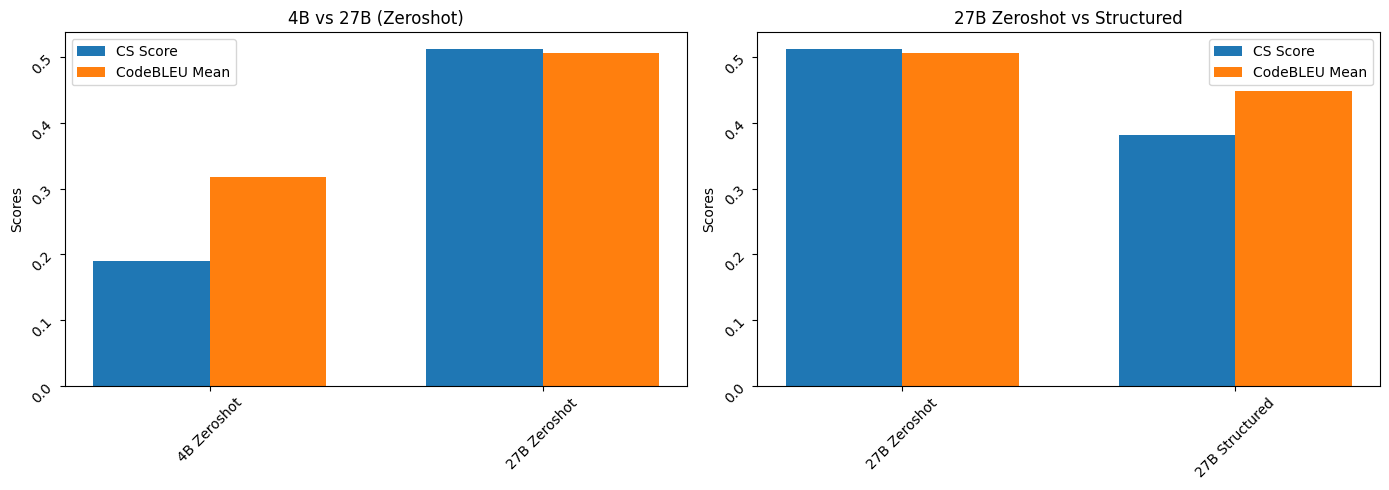

In [21]:
models_1v2 = ['4B Zeroshot', '27B Zeroshot']
cs_1v2 = [d1['cs_overall'], d2['cs_overall']]
cb_1v2 = [d1['codebleu_mean'], d2['codebleu_mean']]

models_2v3 = ['27B Zeroshot', '27B Structured']
cs_2v3 = [d2['cs_overall'], d3['cs_overall']]
cb_2v3 = [d2['codebleu_mean'], d3['codebleu_mean']]

print(f"4B Zeroshot CS: {cs_1v2[0]:.3f}, CodeBLEU: {cb_1v2[0]:.3f}")
print(f"27B Zeroshot CS: {cs_1v2[1]:.3f}, CodeBLEU: {cb_1v2[1]:.3f}")
print(f"27B Structured CS: {cs_2v3[1]:.3f}, CodeBLEU: {cb_2v3[1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
width = 0.35

x1 = np.arange(len(models_1v2))
ax1.bar(x1 - width/2, cs_1v2, width, label='CS Score')
ax1.bar(x1 + width/2, cb_1v2, width, label='CodeBLEU Mean')
ax1.set_ylabel('Scores')
ax1.set_title('4B vs 27B (Zeroshot)')
ax1.set_xticks(x1)
ax1.set_xticklabels(models_1v2)
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=45)
ax1.legend()

x2 = np.arange(len(models_2v3))
ax2.bar(x2 - width/2, cs_2v3, width, label='CS Score')
ax2.bar(x2 + width/2, cb_2v3, width, label='CodeBLEU Mean')
ax2.set_ylabel('Scores')
ax2.set_title('27B Zeroshot vs Structured')
ax2.set_xticks(x2)
ax2.set_xticklabels(models_2v3)
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()


**Observation:**
The 27B Zeroshot model dramatically improves over the 4B model, increasing the CS score from 19.0% to 51.2%. Interestingly, the **27B Structured** approach actually **regresses**, dropping the CS score back to 38.1%.

## 2. Model vs Model Comparisons
### 4B Zeroshot vs 27B Zeroshot
Let's see which specific samples improved or regressed.

In [22]:
def extract_samples(d):
    return {s['id']: s for s in d['per_sample']}

s1 = extract_samples(d1)
s2 = extract_samples(d2)
s3 = extract_samples(d3)
ids = list(s1.keys())

def compare(name_a, s_a, name_b, s_b):
    cs_up = 0
    cs_down = 0
    cb_diff = 0
    status_changes = {}
    
    for id_ in ids:
        if s_a[id_].get('cs_score') is not None and s_b[id_].get('cs_score') is not None:
            score_a = s_a[id_]['cs_score']
            score_b = s_b[id_]['cs_score']
            if score_b > score_a: cs_up += 1
            elif score_b < score_a: cs_down += 1
        
        cb_a = s_a[id_].get('codebleu_score', 0) or 0
        cb_b = s_b[id_].get('codebleu_score', 0) or 0
        cb_diff += (cb_b - cb_a)
        
        stat_a = s_a[id_].get('cs_details', {}).get('status', 'unknown')
        stat_b = s_b[id_].get('cs_details', {}).get('status', 'unknown')
        if stat_a != stat_b:
            change = f'{stat_a} -> {stat_b}'
            status_changes[change] = status_changes.get(change, 0) + 1
            
    print(f"Improvements ({name_b} > {name_a}): {cs_up}")
    print(f"Regressions ({name_b} < {name_a}): {cs_down}")
    print(f"Avg CodeBLEU Change: {cb_diff / len(ids):.4f}")
    print("Status Changes:")
    for k, v in sorted(status_changes.items(), key=lambda x: -x[1]):
        print(f"  {k}: {v}")

print("--- 4B Zeroshot vs 27B Zeroshot ---")
compare('4B_zero', s1, '27B_zero', s2)

--- 4B Zeroshot vs 27B Zeroshot ---
Improvements (27B_zero > 4B_zero): 15
Regressions (27B_zero < 4B_zero): 1
Avg CodeBLEU Change: 0.1879
Status Changes:
  parse_error -> success: 13
  success -> parse_error: 1
  runtime_error -> success: 1
  parse_error -> runtime_error: 1


**Observation:**
Going from 4B to 27B resulted in **15 improvements** and only **1 regression**. Notably, 13 samples went from a `parse_error` to `success`, showing the 27B model outputs much more syntactically valid code.

### 27B Zeroshot vs 27B Structured
Now let's examine why the structured approach performed worse.

In [23]:
print("--- 27B Zeroshot vs 27B Structured ---")
compare('27B_zero', s2, '27B_struct', s3)

--- 27B Zeroshot vs 27B Structured ---
Improvements (27B_struct > 27B_zero): 3
Regressions (27B_struct < 27B_zero): 10
Avg CodeBLEU Change: -0.0575
Status Changes:
  success -> parse_error: 7
  parse_error -> success: 3
  timeout -> parse_error: 1
  success -> runtime_error: 1


**Observation:**
The Structured approach caused **10 regressions** against only 3 improvements. 7 of the successful zero-shot generations turned into `parse_error`s! This indicates that the structured formatting constraint or prompt might be confusing the model into generating invalid syntax.

## 3. Breakdown by Language and Duration
Let's see how performance varies based on programming language and video duration (short, medium, long).

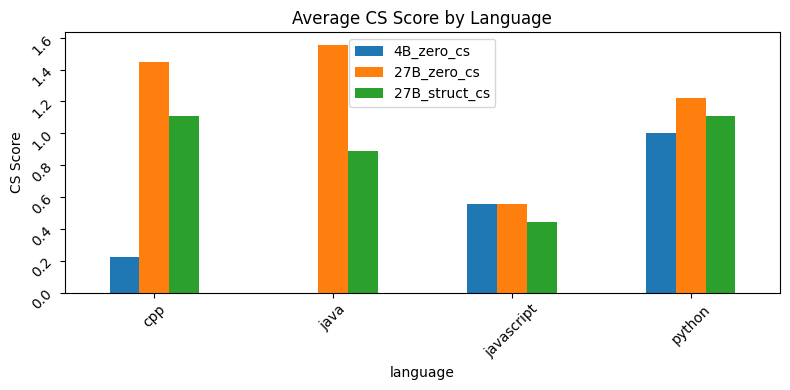

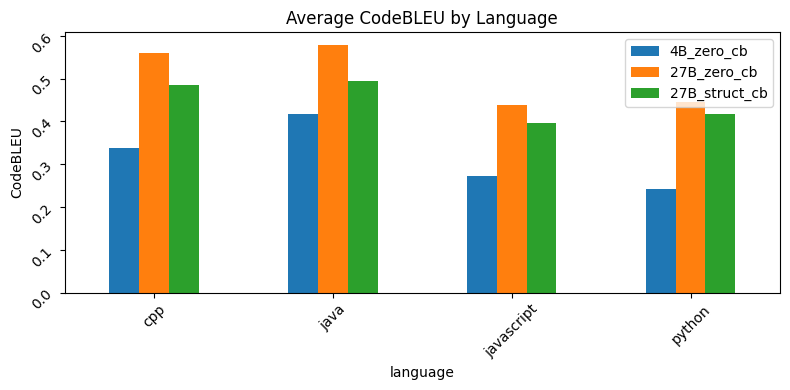

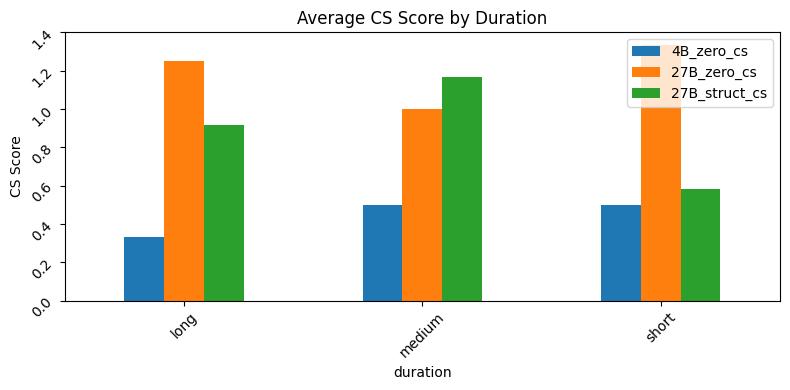

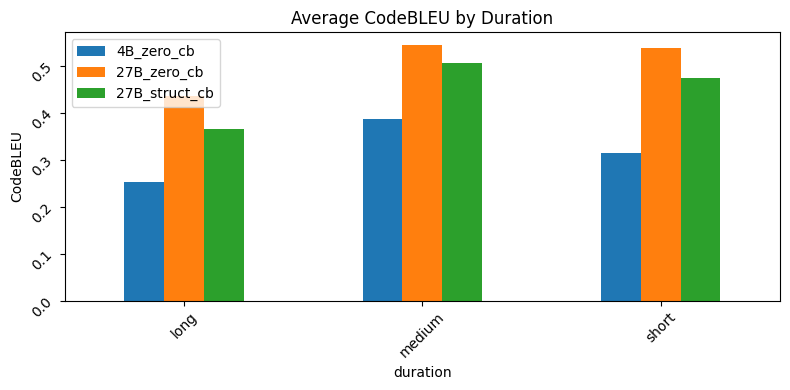

In [25]:
import pandas as pd

def get_df(d, name):
    records = []
    for s in d['per_sample']:
        dur = s['id'].split('/')[1] if '/' in s['id'] else 'unknown'
        records.append({
            'id': s['id'],
            'language': s['language'],
            'duration': dur,
            f'{name}_cs': s.get('cs_score', 0) if s.get('cs_score') is not None else 0,
            f'{name}_cb': s.get('codebleu_score', 0) if s.get('codebleu_score') is not None else 0,
            f'{name}_valid': 1 if s.get('cs_details', {}).get('status') == 'success' else 0
        })
    return pd.DataFrame(records)

df1 = get_df(d1, '4B_zero')
df2 = get_df(d2, '27B_zero')
df3 = get_df(d3, '27B_struct')

df = df1.merge(df2, on=['id', 'language', 'duration']).merge(df3, on=['id', 'language', 'duration'])

# Language breakdown - CS
lang_cs = df.groupby('language')[['4B_zero_cs', '27B_zero_cs', '27B_struct_cs']].mean()
ax = lang_cs.plot(kind='bar', figsize=(8, 4), title="Average CS Score by Language")
ax.set_ylabel("CS Score")
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=45)
plt.tight_layout()
plt.show()

# Language breakdown - CodeBLEU
lang_cb = df.groupby('language')[['4B_zero_cb', '27B_zero_cb', '27B_struct_cb']].mean()
ax_cb = lang_cb.plot(kind='bar', figsize=(8, 4), title="Average CodeBLEU by Language")
ax_cb.set_ylabel("CodeBLEU")
ax_cb.tick_params(axis='x', rotation=45)
ax_cb.tick_params(axis='y', rotation=45)
plt.tight_layout()
plt.show()

# Duration breakdown - CS
dur_cs = df.groupby('duration')[['4B_zero_cs', '27B_zero_cs', '27B_struct_cs']].mean()
ax2 = dur_cs.plot(kind='bar', figsize=(8, 4), title="Average CS Score by Duration")
ax2.set_ylabel("CS Score")
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=45)
plt.tight_layout()
plt.show()

# Duration breakdown - CodeBLEU
dur_cb = df.groupby('duration')[['4B_zero_cb', '27B_zero_cb', '27B_struct_cb']].mean()
ax2_cb = dur_cb.plot(kind='bar', figsize=(8, 4), title="Average CodeBLEU by Duration")
ax2_cb.set_ylabel("CodeBLEU")
ax2_cb.tick_params(axis='x', rotation=45)
ax2_cb.tick_params(axis='y', rotation=45)
plt.tight_layout()
plt.show()


## 4. Detailed Breakdown of 1 vs 2 and 2 vs 3
Let's look at exactly where the improvements and regressions are happening across these dimensions.

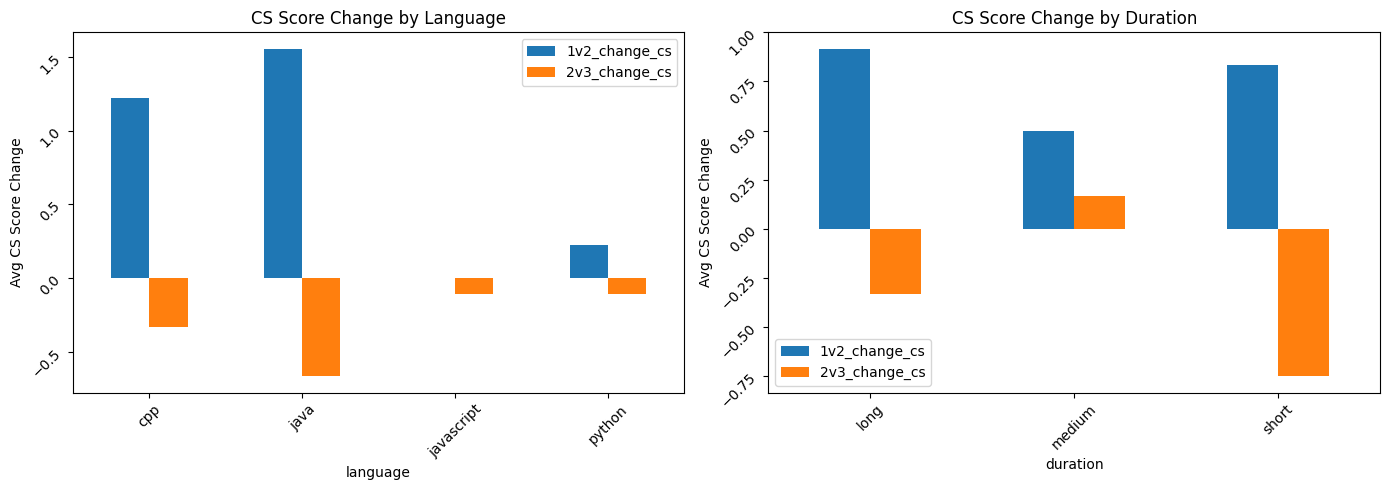

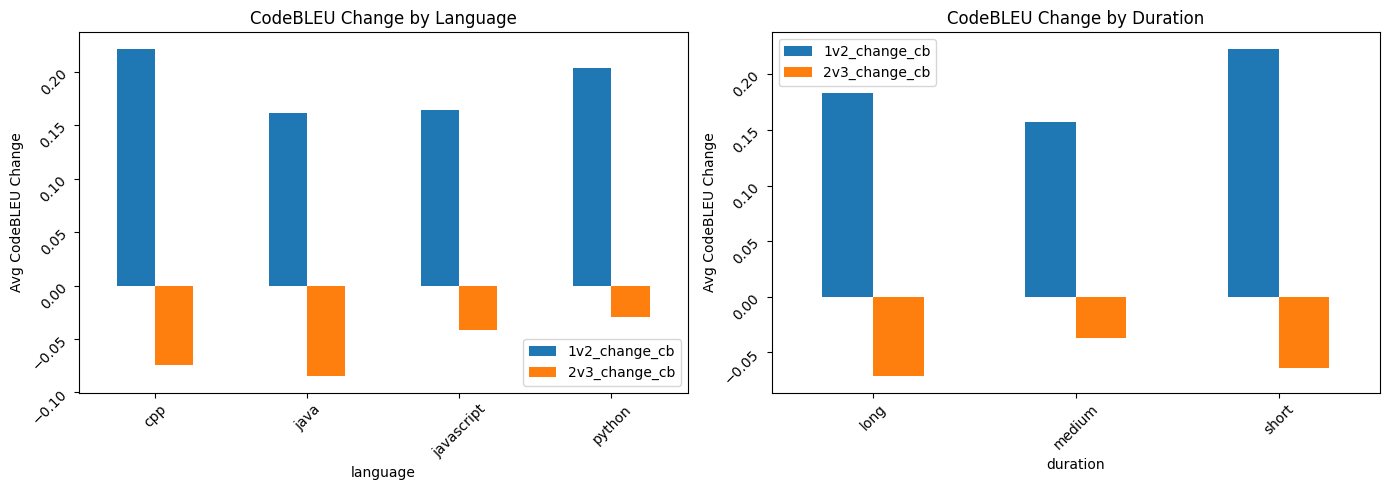

In [26]:
df['1v2_change_cs'] = df['27B_zero_cs'] - df['4B_zero_cs']
df['2v3_change_cs'] = df['27B_struct_cs'] - df['27B_zero_cs']
df['1v2_change_cb'] = df['27B_zero_cb'] - df['4B_zero_cb']
df['2v3_change_cb'] = df['27B_struct_cb'] - df['27B_zero_cb']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.groupby('language')[['1v2_change_cs', '2v3_change_cs']].mean().plot(kind='bar', ax=axes[0], title='CS Score Change by Language')
axes[0].set_ylabel('Avg CS Score Change')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=45)
df.groupby('duration')[['1v2_change_cs', '2v3_change_cs']].mean().plot(kind='bar', ax=axes[1], title='CS Score Change by Duration')
axes[1].set_ylabel('Avg CS Score Change')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=45)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
df.groupby('language')[['1v2_change_cb', '2v3_change_cb']].mean().plot(kind='bar', ax=axes2[0], title='CodeBLEU Change by Language')
axes2[0].set_ylabel('Avg CodeBLEU Change')
axes2[0].tick_params(axis='x', rotation=45)
axes2[0].tick_params(axis='y', rotation=45)
df.groupby('duration')[['1v2_change_cb', '2v3_change_cb']].mean().plot(kind='bar', ax=axes2[1], title='CodeBLEU Change by Duration')
axes2[1].set_ylabel('Avg CodeBLEU Change')
axes2[1].tick_params(axis='x', rotation=45)
axes2[1].tick_params(axis='y', rotation=45)
plt.tight_layout()
plt.show()


## Conclusion
- **27B Zeroshot** is clearly the superior model in this evaluation, dominating the CS Score.
- The **Structured** constraint hurts the 27B model, leading to many `parse_error`s that were otherwise successful in the zeroshot approach. This might require debugging the prompt or post-processing pipeline for the structured approach.